In [220]:
import numpy as np
import pandas as pd

In [221]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split
from surprise import accuracy
from surprise.model_selection import cross_validate

In [222]:
path = "fake_interactions/interactions_data_5000_user/"

In [223]:
df_movies = pd.read_csv(path + 'movies_data.csv')
df_interactions = pd.read_csv(path + 'interactions_data.csv')

In [224]:
df_movies.head()

,id,title,description,genres,actors,directors
0,37702,Forbidden City Cop,An imperial agent gets ridiculed for his vario...,"Adventure, Action, Comedy","Stephen Chow, Carina Lau, Carman Lee Yeuk-Tung...",Vincent Kok Tak-Chiu
1,1290821,Shelter,A man living in self-imposed exile on a remote...,"Action, Thriller, Crime","Jason Statham, Bodhi Rae Breathnach, Bill Nigh...",Ric Roman Waugh
2,1171145,Crime 101,When an elusive thief whose high-stakes heists...,"Thriller, Crime","Chris Hemsworth, Mark Ruffalo, Halle Berry, Ba...",Bart Layton
3,1198994,Send Help,Two colleagues become stranded on a deserted i...,"Horror, Comedy, Thriller","Rachel McAdams, Dylan O'Brien, Edyll Ismail, D...",Sam Raimi
4,840464,Greenland 2: Migration,Having found the safety of the Greenland bunke...,"Adventure, Thriller, Science Fiction","Gerard Butler, Morena Baccarin, Roman Griffin ...",Ric Roman Waugh


In [225]:
df_movies.rename(columns={'id': 'movie_id', 'title': 'title', 'genres': 'genres'}, inplace=True)

In [226]:
def calculate_base_score(row, weights):
    v_progress = row['max_progress_percent'] / 100
    v_rating = row['rating'] / 5.0 if pd.notnull(row['rating']) else None
    v_fav = float(row['favourite'])
    v_watchlist = float(row['in_watchlist'])
    v_view_count = np.log(max(row['view_count'], 1)) / np.log(10)

    # Tính điểm theo từng thành phần hợp lệ
    numerator = (
        weights['progress'] * v_progress
        + weights['favourite'] * v_fav
        + weights['watchlist'] * v_watchlist
        + weights['view_count'] * v_view_count
    )
    denominator = (
        weights['progress']
        + weights['favourite']
        + weights['watchlist']
        + weights['view_count']
    )

    # Chỉ cộng rating khi có dữ liệu
    if v_rating is not None:
        numerator += weights['rating'] * v_rating
        denominator += weights['rating']

    return numerator / denominator * 10

In [227]:
weights = {
    'progress': 3.0,
    'rating': 4.1,
    'favourite': 4.5,
    'watchlist': 2.0,
    'view_count': 1.1
}

df_interactions['base_score'] = df_interactions.apply(calculate_base_score, axis=1, weights=weights)

In [228]:
def add_time_features(df):
    df = df.copy()
    df["last_watched_at"] = pd.to_datetime(
        df["last_watched_at"], errors="coerce"
    )
    today = pd.Timestamp.now().normalize()
    df["day_diff"] = (
        today - df["last_watched_at"].dt.normalize()
    ).dt.days

    return df

In [229]:
df_interactions = add_time_features(df_interactions)
df_interactions.head()

,user_id,movie_id,rating,max_progress_percent,favourite,in_watchlist,view_count,last_watched_at,base_score,day_diff
0,10,9315,NaN,25,0,1,1,2026-02-09 23:51:55.273267,2.594340,52
1,10,319888,2.0,45,0,0,1,2025-12-12 23:51:55.273267,2.034014,111
2,10,33205,NaN,35,0,0,1,2026-02-04 23:51:55.274268,0.990566,57
3,10,664561,NaN,31,0,1,1,2025-12-26 23:51:55.275265,2.764151,97
4,10,9013,NaN,19,0,0,1,2025-10-10 23:51:55.275265,0.537736,174


In [230]:
# Xác định decay factor lambda dựa trên nửa đời (half-life)
HALF_LIFE_DAYS = 30
decay_lambda = np.log(2) / HALF_LIFE_DAYS

print(f"Decay factor (lambda) for a half-life of {HALF_LIFE_DAYS} days: {decay_lambda:.6f}")

Decay factor (lambda) for a half-life of 30 days: 0.023105


In [231]:
def cal_score_on_time(df, lam):
    df = df.copy()

    df['heuristic_score'] = df['base_score'] * np.exp(-lam * df['day_diff'])

    return df

In [232]:
df_interactions = cal_score_on_time(df_interactions, decay_lambda)
df_interactions

,user_id,movie_id,rating,max_progress_percent,favourite,in_watchlist,view_count,last_watched_at,base_score,day_diff,heuristic_score
0,10,9315,NaN,25,0,1,1,2026-02-09 23:51:55.273267,2.594340,52,0.780264
1,10,319888,2.0,45,0,0,1,2025-12-12 23:51:55.273267,2.034014,111,0.156510
2,10,33205,NaN,35,0,0,1,2026-02-04 23:51:55.274268,0.990566,57,0.265416
3,10,664561,NaN,31,0,1,1,2025-12-26 23:51:55.275265,2.764151,97,0.293922
4,10,9013,NaN,19,0,0,1,2025-10-10 23:51:55.275265,0.537736,174,0.009652
...,...,...,...,...,...,...,...,...,...,...,...
275052,5000,299,4.0,92,0,0,3,2026-01-20 00:16:43.092657,4.465873,72,0.846125
275053,5000,927,NaN,33,0,0,1,2026-01-01 00:16:43.093612,0.933962,91,0.114079
275054,5000,564147,4.0,77,0,0,2,2025-12-02 00:16:43.095954,4.027982,121,0.245999
275055,5000,152042,5.0,89,1,0,4,2026-01-28 00:16:43.095954,8.117188,64,1.850156


In [233]:
from collections import Counter

In [234]:
# Algorithm 1: Phân loại thể loại yêu thích và không thích của người dùng
# Lấy trung vị (median)

def get_user_genres_preferences(user_id, df_interaction, df_items):
  # Get movieId which user rated
  user_ratings = df_interactions[df_interaction['user_id'] == user_id]

  # Count genre
  genre_counts = Counter()
  for m_id in user_ratings['movie_id']:
    genre_str = df_items.loc[df_items['movie_id'] == m_id, 'genres'].values[0]
    if pd.isna(genre_str): continue
    for genre in genre_str.split(', '):
      genre_counts[genre] += 1

  # Get all genre
  all_genres = set()
  df_items['genres'].str.split(', ').apply(lambda x: all_genres.update(x) if isinstance(x, list) else None)

  # Sort asc
  sorted_genres = sorted(list(all_genres), key=lambda x: genre_counts.get(x, 0), reverse=True)

  # Find mid-point
  mid_point = len(sorted_genres) // 2
  fav_genres = sorted_genres[:mid_point]
  unfav_genres = sorted_genres[mid_point:]

  return fav_genres, unfav_genres, genre_counts


In [235]:
# Algorithm 2: Kiểm tra tính liên quan (Relevance) dựa trên Genre
def is_movie_relevant(movie_id, df_movies, fav_genres, unfav_genres):
    res = df_movies.loc[df_movies['movie_id'] == movie_id, 'genres'].values
    if len(res) == 0 or pd.isna(res[0]): return False

    movie_genres = [g.strip() for g in res[0].split(', ')]
    # Score = (Số genre thích) - (Số genre ghét)
    score = sum(1 for g in movie_genres if g in fav_genres) - \
            sum(1 for g in movie_genres if g in unfav_genres)
    return score > 0

In [236]:
def get_user_genres_preferences_on_time(user_id, df_interaction, df_items):
    user_ratings = df_interaction[df_interaction['user_id'] == user_id]
    
    if user_ratings.empty:
        return [], [], Counter()

    movie_genre_map = df_items.set_index('movie_id')['genres'].to_dict()

    genre_counts = Counter()
    for _, row in user_ratings.iterrows():
        m_id = row['movie_id']
        score = row['heuristic_score']
        
        genre_str = movie_genre_map.get(m_id, "")
        if pd.isna(genre_str) or genre_str == "": 
            continue
            
        genres = [g.strip() for g in genre_str.replace('|', ', ').split(', ')]
        for genre in genres:
            genre_counts[genre] += score 

    if not genre_counts:
        return [], [], genre_counts
        
    total_score = sum(genre_counts.values())
    num_genres_interacted = len(genre_counts)
    avg_score = total_score / num_genres_interacted

    print("avg_score:", avg_score)

    sorted_genres = sorted(genre_counts.items(), key=lambda x: x[1], reverse=True)
    
    fav_genres = [g for g, score in sorted_genres if score > avg_score]
    unfav_genres = [g for g, score in sorted_genres if score <= avg_score]

    return fav_genres, unfav_genres, genre_counts, avg_score

In [237]:
def is_movie_relevant_weighted(movie_id, df_movies, genre_counts, avg_score):
    res = df_movies.loc[df_movies['movie_id'] == movie_id, 'genres'].values
    if len(res) == 0 or pd.isna(res[0]): return False

    movie_genres = [g.strip() for g in res[0].split(',')]
    
    total_movie_genre_score = sum(genre_counts.get(g, 0) for g in movie_genres)
    avg_movie_genre_score = total_movie_genre_score / len(movie_genres)

    print(f"Movie ID {movie_id} - Avg Genre Score: {avg_movie_genre_score:.2f}, User Avg Score: {avg_score:.2f}")
    return avg_movie_genre_score > avg_score

In [238]:
reader = Reader(rating_scale=(0, 10))
data = Dataset.load_from_df(df_interactions[['user_id', 'movie_id', 'heuristic_score']], reader)

trainset = data.build_full_trainset()

In [239]:
algorithms = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02)

In [240]:
algorithms.fit(trainset)

In [241]:
import pandas as pd

def get_recommendations_for_user(user_id, algorithms, df_interaction, df_movies, k=15):
    interacted_movie_ids = set(df_interaction[df_interaction['user_id'] == user_id]['movie_id'])

    all_movie_ids = set(df_movies['movie_id'])
    non_interacted_movie_ids = list(all_movie_ids - interacted_movie_ids)

    predictions = []
    for movie_id in non_interacted_movie_ids:
        est = algorithms.predict(user_id, movie_id).est
        predictions.append({'movie_id': movie_id, 'predict_score': est})

    df_predictions = pd.DataFrame(predictions)

    df_top_k = df_predictions.sort_values(by='predict_score', ascending=False).head(k)

    result = pd.merge(df_top_k, df_movies, on='movie_id', how='left')

    return result[['movie_id', 'title', 'genres', 'predict_score']]



# Recommendation với user cụ thể: user_id = 10

In [242]:
# USER_ID = 1123

In [243]:
# fav, unfav, genre_counts = get_user_genres_preferences(USER_ID, df_interactions, df_movies)

# import matplotlib.pyplot as plt
# import seaborn as sns

# def plot_genre_with_mean(genre_counts, user_id):
#     df_plot = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['score']).reset_index()
#     df_plot.columns = ['genre', 'score']
#     df_plot = df_plot.sort_values(by='score', ascending=False)

#     plt.figure(figsize=(12, 7))
#     sns.barplot(x='score', y='genre', data=df_plot, palette='magma')

    
#     plt.title(f'Genre Analysis for User {user_id}', fontsize=16)
#     plt.legend() # Hiển thị chú thích cho đường Mean
#     plt.show()

# plot_genre_with_mean(genre_counts, USER_ID)
# print("Fav genres:", fav)

# rcm = get_recommendations_for_user(10, algorithms, df_interactions, df_movies, k=15)
# rcm["is_relevant"] = rcm['movie_id'].apply(lambda m_id: is_movie_relevant(m_id, df_movies, fav, unfav))
# rcm

In [244]:
# fav, unfav, genre_counts = get_user_genres_preferences(USER_ID, df_interactions, df_movies)


In [245]:
# count_relevant = 0
# for row in rcm.itertuples():
#     if is_movie_relevant(row.movie_id, df_movies, fav, unfav):
#         print(f"Movie ID {row.movie_id} is relevant to user {USER_ID}.")
#         count_relevant += 1
        

# print(f"Total relevant movies in top 15 recommendations: {count_relevant/ 15}")

In [249]:
USER_ID = 24

avg_score: 4.569477870694026


C:\Users\Admin\AppData\Local\Temp\ipykernel_20212\1466284886.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='score', y='genre', data=df_plot, palette='magma')


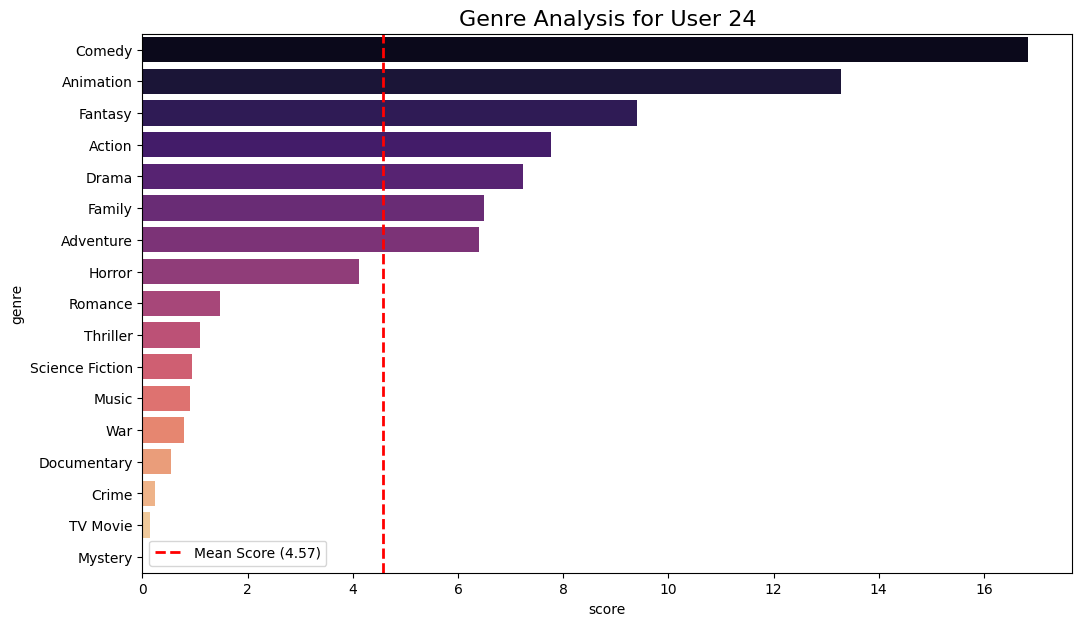

Movie ID 11282 - Avg Genre Score: 11.62, User Avg Score: 4.57
Movie ID 5375 - Avg Genre Score: 10.62, User Avg Score: 4.57
Movie ID 12254 - Avg Genre Score: 6.43, User Avg Score: 4.57
Movie ID 400136 - Avg Genre Score: 6.50, User Avg Score: 4.57
Movie ID 377462 - Avg Genre Score: 0.26, User Avg Score: 4.57
Movie ID 680813 - Avg Genre Score: 6.91, User Avg Score: 4.57
Movie ID 1432596 - Avg Genre Score: 2.67, User Avg Score: 4.57
Movie ID 273477 - Avg Genre Score: 10.48, User Avg Score: 4.57
Movie ID 254172 - Avg Genre Score: 7.23, User Avg Score: 4.57
Movie ID 811043 - Avg Genre Score: 6.81, User Avg Score: 4.57
Movie ID 1238188 - Avg Genre Score: 3.62, User Avg Score: 4.57
Movie ID 929204 - Avg Genre Score: 10.75, User Avg Score: 4.57
Movie ID 13127 - Avg Genre Score: 4.08, User Avg Score: 4.57
Movie ID 11633 - Avg Genre Score: 7.33, User Avg Score: 4.57
Movie ID 12890 - Avg Genre Score: 8.52, User Avg Score: 4.57


,movie_id,title,genres,predict_score,is_relevant
0,11282,Harold & Kumar Go to White Castle,"Adventure, Comedy",1.810641,True
1,5375,Fred Claus,"Drama, Action, Comedy",1.747910,True
2,12254,Emma,"Drama, Comedy, Romance, TV Movie",1.728304,True
3,400136,Resident Evil: Vendetta,"Adventure, Animation, Horror, Action, Science ...",1.707100,True
4,377462,O.J.: Made in America,"History, Crime, Documentary",1.685358,False
5,680813,Flee,"Animation, Documentary",1.650041,True
6,1432596,Palestine 36,"Drama, History, War",1.598100,False
7,273477,Scouts Guide to the Zombie Apocalypse,"Horror, Comedy",1.597968,True
8,254172,Fathers and Daughters,Drama,1.595198,True
9,811043,The Towers of Musahino Line,"Adventure, Drama",1.589842,True


In [250]:
fav, unfav, genre_counts, avg_score = get_user_genres_preferences_on_time(USER_ID, df_interactions, df_movies)

import matplotlib.pyplot as plt
import seaborn as sns

def plot_genre_with_mean(genre_counts, avg_score, user_id):
    df_plot = pd.DataFrame.from_dict(genre_counts, orient='index', columns=['score']).reset_index()
    df_plot.columns = ['genre', 'score']
    df_plot = df_plot.sort_values(by='score', ascending=False)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='score', y='genre', data=df_plot, palette='magma')

    # VẼ ĐƯỜNG TRUNG BÌNH
    plt.axvline(x=avg_score, color='red', linestyle='--', linewidth=2, label=f'Mean Score ({avg_score:.2f})')
    
    plt.title(f'Genre Analysis for User {user_id}', fontsize=16)
    plt.legend() # Hiển thị chú thích cho đường Mean
    plt.show()

plot_genre_with_mean(genre_counts, avg_score, USER_ID)

rcm = get_recommendations_for_user(USER_ID, algorithms, df_interactions, df_movies, k=15)

rcm["is_relevant"] = rcm['movie_id'].apply(lambda m_id: is_movie_relevant_weighted(m_id, df_movies, genre_counts, avg_score))
rcm

In [251]:
count_relevant = 0
for row in rcm.itertuples():
    if is_movie_relevant_weighted(row.movie_id, df_movies, genre_counts, avg_score):
        count_relevant += 1
        

print(f"Total relevant movies in top 15 recommendations: {count_relevant/ 15}")

Movie ID 11282 - Avg Genre Score: 11.62, User Avg Score: 4.57
Movie ID 5375 - Avg Genre Score: 10.62, User Avg Score: 4.57
Movie ID 12254 - Avg Genre Score: 6.43, User Avg Score: 4.57
Movie ID 400136 - Avg Genre Score: 6.50, User Avg Score: 4.57
Movie ID 377462 - Avg Genre Score: 0.26, User Avg Score: 4.57
Movie ID 680813 - Avg Genre Score: 6.91, User Avg Score: 4.57
Movie ID 1432596 - Avg Genre Score: 2.67, User Avg Score: 4.57
Movie ID 273477 - Avg Genre Score: 10.48, User Avg Score: 4.57
Movie ID 254172 - Avg Genre Score: 7.23, User Avg Score: 4.57
Movie ID 811043 - Avg Genre Score: 6.81, User Avg Score: 4.57
Movie ID 1238188 - Avg Genre Score: 3.62, User Avg Score: 4.57
Movie ID 929204 - Avg Genre Score: 10.75, User Avg Score: 4.57
Movie ID 13127 - Avg Genre Score: 4.08, User Avg Score: 4.57
Movie ID 11633 - Avg Genre Score: 7.33, User Avg Score: 4.57
Movie ID 12890 - Avg Genre Score: 8.52, User Avg Score: 4.57
Total relevant movies in top 15 recommendations: 0.7333333333333333
